**Project 17-Urban_Logistics_Demand_Forecasting**

**Authored by:** SAHITHI PINNAM

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Pandas, NumPy, Matplotlib, basic data analysis data visualisation, and basic machine learning or deep learning concepts.

**Scenario:** As a logistics planner or city analyst in Melbourne, I want to predict logistics demand across different regions and time periods so that delivery planning and resource allocation can be improved.
This project focuses on analysing transport activity data to understand patterns related to delivery demand, especially for vehicles such as vans and trucks.

**What this use case will teach you:** By the end of this use case you will have:
• Collected multiple years of Melbourne transport activity datasets
• Cleaned and prepared the data for analysis
• Filtered relevant vehicle types for logistics demand
• Created time-based features for demand analysis
• Prepared the dataset for forecasting and prediction

**Introduction:** Urban logistics demand varies depending on time, location, and traffic activity. This project focuses on analysing transport activity data to identify patterns related to delivery demand. By combining multiple years of data and focusing on logistics-related vehicle types, this project prepares the dataset for forecasting and demand prediction.

**Datasets Used:** Transport Activity Counts (City of Melbourne Open Data)
https://data.melbourne.vic.gov.au/explore/dataset/transport-activity-counts/export/

**Use:** Transport activity data used to analyse logistics demand patterns across time and locations.
Transport Activity Counts (2023-2026 datasets)

**Source:** City of Melbourne Open Data attachments
Use: Combined multi-year dataset for improved forecasting and analysis.


**Loading and Combining Datasets:**
This section loads transport activity datasets from multiple years (2023–2026) using Python. The code downloads ZIP files from the City of Melbourne Open Data portal, extracts CSV files, and reads them into Pandas dataframes. All datasets are then combined into one large dataframe using pd.concat(). Combining multiple years of data helps create a comprehensive dataset for analysing logistics demand trends across different time periods and locations.

In [6]:
import requests
import zipfile
import io
import pandas as pd

urls = ["https://raw.githubusercontent.com/Chameleon-company/MOP-Code/a2142d6ebde2ef3d9b57365dba0092216b42b642/datascience/usecases/DEPENDENCIES/Urban_Logistic_Demand_Forecasting/TransportActivityCount_2023.zip",
       "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/a2142d6ebde2ef3d9b57365dba0092216b42b642/datascience/usecases/DEPENDENCIES/Urban_Logistic_Demand_Forecasting/TransportActivityCount_2024.zip",
       "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/a2142d6ebde2ef3d9b57365dba0092216b42b642/datascience/usecases/DEPENDENCIES/Urban_Logistic_Demand_Forecasting/TransportActivityCount_2025.zip",
       "https://raw.githubusercontent.com/Chameleon-company/MOP-Code/a2142d6ebde2ef3d9b57365dba0092216b42b642/datascience/usecases/DEPENDENCIES/Urban_Logistic_Demand_Forecasting/TransportActivityCount_2026.zip",]



all_dfs = []

for url in urls:
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    for file in z.namelist():
        if file.endswith(".csv"):
            try:
                df = pd.read_csv(z.open(file), encoding="utf-8")
            except UnicodeDecodeError:
                df = pd.read_csv(z.open(file), encoding="latin1")
            all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)
final_df = final_df.loc[:, ~final_df.columns.str.contains("^Unnamed")]


print(final_df.shape)
print(final_df.head())


(14324172, 8)
   countLocationId               countLocationName  CountLocationLat  \
0          45040.0  Queens Bridge Street - CoM1549        -37.820920   
1          45471.0   La Trobe St- William St I-Hub        -37.811920   
2          43891.0   Swanston St Asset ID: COM1757        -37.808159   
3          45038.0  Queens Bridge Street - CoM1549        -37.820920   
4          45472.0   La Trobe St- William St I-Hub        -37.811920   

   CountLocationLong                      from                        to  \
0         144.961642  2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z   
1         144.956251  2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z   
2         144.963052  2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z   
3         144.961642  2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z   
4         144.956251  2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z   

     class  count  
0  cyclist    1.0  
1      car   36.0  
2  cyclist    1.0  
3      van    1.

**Renaming Columns:**
In this step, the column names are renamed to make them easier to understand and work with. The original dataset contains long and inconsistent column names, so they are replaced with simpler names such as location_id, location_name, vehicle_type, and vehicle_count. Renaming columns improves readability and makes future data processing easier.

In [7]:
#Rename columns
final_df.rename(columns={
    "countLocationId": "location_id",
    "countLocationName": "location_name",
    "CountLocationLat": "latitude",
    "CountLocationLong": "longitude",
    "from": "start_time",
    "to": "end_time",
    "class": "vehicle_type",
    "count": "vehicle_count"
}, inplace=True)
print(final_df.columns)

Index(['location_id', 'location_name', 'latitude', 'longitude', 'start_time',
       'end_time', 'vehicle_type', 'vehicle_count'],
      dtype='object')


**Filtering Vans and Trucks:**
This step filters the dataset to include only vans and trucks. These vehicle types are more relevant for logistics demand because they are commonly used for deliveries and transportation. The filtered dataset is stored in a new dataframe called van_truck_df, which will be used for further analysis.

In [8]:
# filter only vans and trucks
final_df.rename(columns={"class": "vehicle_type"}, inplace=True)
van_truck_df = final_df[final_df["vehicle_type"].isin(["van", "truck"])]

print(van_truck_df.head())
print("Number of rows:", van_truck_df.shape[0])

    location_id                   location_name  latitude   longitude  \
3       45038.0  Queens Bridge Street - CoM1549 -37.82092  144.961642   
72      45471.0   La Trobe St- William St I-Hub -37.81192  144.956251   
78      45472.0   La Trobe St- William St I-Hub -37.81192  144.956251   
94      45471.0   La Trobe St- William St I-Hub -37.81192  144.956251   
99      45472.0   La Trobe St- William St I-Hub -37.81192  144.956251   

                  start_time                  end_time vehicle_type  \
3   2023-10-01T00:00:00.000Z  2023-10-01T00:05:00.000Z          van   
72  2023-10-01T00:10:00.000Z  2023-10-01T00:15:00.000Z          van   
78  2023-10-01T00:10:00.000Z  2023-10-01T00:15:00.000Z          van   
94  2023-10-01T00:15:00.000Z  2023-10-01T00:20:00.000Z          van   
99  2023-10-01T00:15:00.000Z  2023-10-01T00:20:00.000Z          van   

    vehicle_count  
3             1.0  
72            1.0  
78            1.0  
94            2.0  
99            1.0  
Number of rows

**Checking Missing Data:**
This section checks for missing or empty values in the dataset. Identifying missing data is important to ensure data quality before performing analysis. The code checks both empty rows and empty columns. The results show that there are no missing rows or columns, meaning the dataset is clean and ready for further processing.

In [9]:
# Find rows where all values are missing
empty_rows = van_truck_df[van_truck_df.isnull().all(axis=1)]
print("Number of completely empty rows:", empty_rows.shape[0])

# Find columns where all values are missing
empty_columns = van_truck_df.columns[van_truck_df.isnull().all()]
print("Empty columns:", list(empty_columns))

Number of completely empty rows: 0
Empty columns: []


**Converting Date and Time:**
In this step, the start_time and end_time columns are converted into datetime format. This allows time-based analysis such as extracting year, month, and hour. Converting date and time values helps prepare the dataset for time-series analysis and forecasting.

In [10]:
# Convert start_time to datetime
van_truck_df = final_df[final_df["vehicle_type"].isin(["van", "truck"])].copy()
van_truck_df["start_time"] = pd.to_datetime(van_truck_df["start_time"], errors="coerce")
van_truck_df["end_time"] = pd.to_datetime(van_truck_df["end_time"], errors="coerce")

**Creating Time Features:**
This section creates new time-based features from the start_time column. These features include year, month, day, hour, and day of the week. These new columns help analyse logistics demand patterns based on time and identify peak delivery periods.

In [11]:
# Hour of day
van_truck_df["year"] = van_truck_df["start_time"].dt.year
van_truck_df["month"] = van_truck_df["start_time"].dt.month
van_truck_df["day"] = van_truck_df["start_time"].dt.day
van_truck_df["hour"] = van_truck_df["start_time"].dt.hour
van_truck_df["day_of_week"] = van_truck_df["start_time"].dt.day_name()

**Display Processed Data:**
This step displays the total number of rows and preview of the processed dataset. This helps confirm that the dataset has been successfully cleaned and transformed. The output shows that time-based features have been added correctly.

In [12]:
print("Total rows:", van_truck_df.shape[0])
print(van_truck_df.head())

Total rows: 760269
    location_id                   location_name  latitude   longitude  \
3       45038.0  Queens Bridge Street - CoM1549 -37.82092  144.961642   
72      45471.0   La Trobe St- William St I-Hub -37.81192  144.956251   
78      45472.0   La Trobe St- William St I-Hub -37.81192  144.956251   
94      45471.0   La Trobe St- William St I-Hub -37.81192  144.956251   
99      45472.0   La Trobe St- William St I-Hub -37.81192  144.956251   

                  start_time                  end_time vehicle_type  \
3  2023-10-01 00:00:00+00:00 2023-10-01 00:05:00+00:00          van   
72 2023-10-01 00:10:00+00:00 2023-10-01 00:15:00+00:00          van   
78 2023-10-01 00:10:00+00:00 2023-10-01 00:15:00+00:00          van   
94 2023-10-01 00:15:00+00:00 2023-10-01 00:20:00+00:00          van   
99 2023-10-01 00:15:00+00:00 2023-10-01 00:20:00+00:00          van   

    vehicle_count  year  month  day  hour day_of_week  
3             1.0  2023     10    1     0      Sunday  
72 

**Aggregating by Location and Year:**
This section groups the dataset by year, location ID, and location name. It then calculates total vehicle counts for each location. This helps identify busy logistics areas and compare demand across different years.

In [13]:
agg_location_year = van_truck_df.groupby(["year", "location_id", "location_name"])["vehicle_count"].sum().reset_index()
print(agg_location_year.head())

   year  location_id                     location_name  vehicle_count
0  2023      43772.0  Southbank Prom Asset ID: COM1598         1212.0
1  2023      44862.0       Royal Park Asset ID:COM2705           31.0
2  2023      44863.0       Royal Park Asset ID:COM2705            5.0
3  2023      44864.0       Royal Park Asset ID:COM2705            3.0
4  2023      45038.0    Queens Bridge Street - CoM1549       137666.0


**Yearly Demand Visualization:**
This step creates a bar chart showing yearly logistics demand. The dataset is grouped by year, and total vehicle counts are calculated. The bar chart helps visualise how logistics demand changes over time.

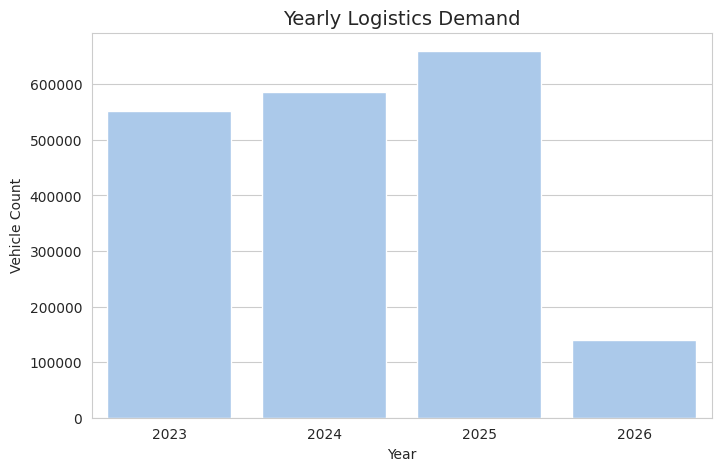

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("pastel")

yearly_demand = van_truck_df.groupby("year")["vehicle_count"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=yearly_demand, x="year", y="vehicle_count")

plt.title("Yearly Logistics Demand", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Vehicle Count")

plt.show()


**Top 10 Busy Locations:**
This section identifies the top 10 locations with the highest logistics demand. The dataset is grouped by location name and sorted by vehicle count. A bar chart is created to show the busiest logistics areas.

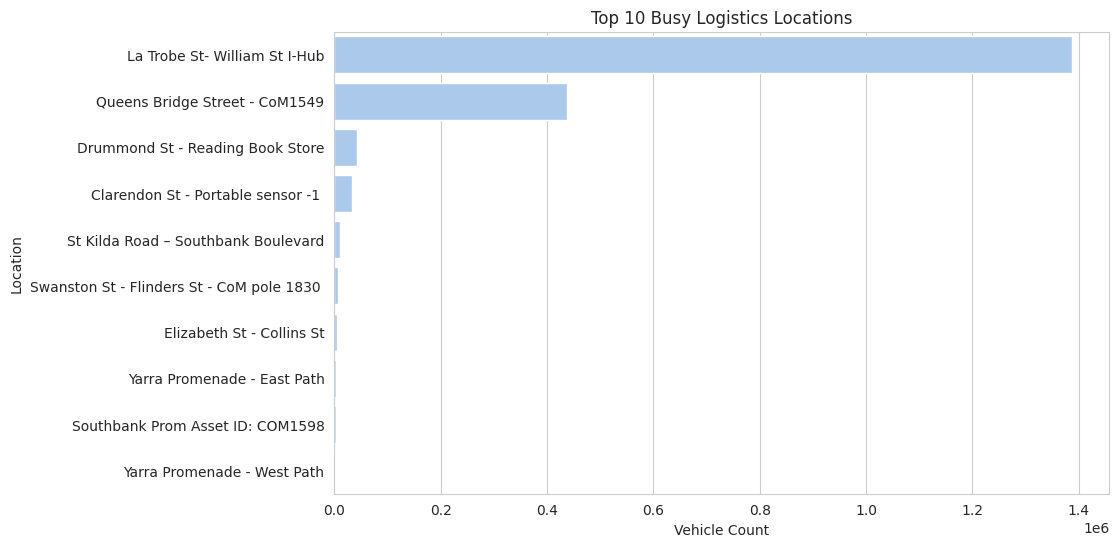

In [15]:
top_locations = van_truck_df.groupby("location_name")["vehicle_count"].sum().reset_index()
top_locations = top_locations.sort_values("vehicle_count", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_locations, y="location_name", x="vehicle_count")

plt.title("Top 10 Busy Logistics Locations")
plt.xlabel("Vehicle Count")
plt.ylabel("Location")

plt.show()

**Hourly Demand Analysis:**
This step analyses logistics demand by hour of the day. The dataset is grouped by hour and visualised using a line chart. This helps identify peak delivery times.

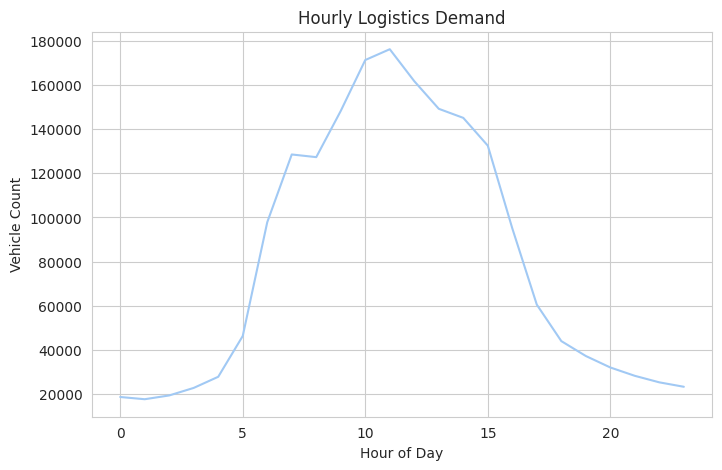

In [16]:
hourly_demand = van_truck_df.groupby("hour")["vehicle_count"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=hourly_demand, x="hour", y="vehicle_count")

plt.title("Hourly Logistics Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Vehicle Count")

plt.show()

**Demand by Day of Week:**
This section analyses logistics demand based on the day of the week. The results are visualised using a bar chart. This helps identify which days have higher delivery activity.

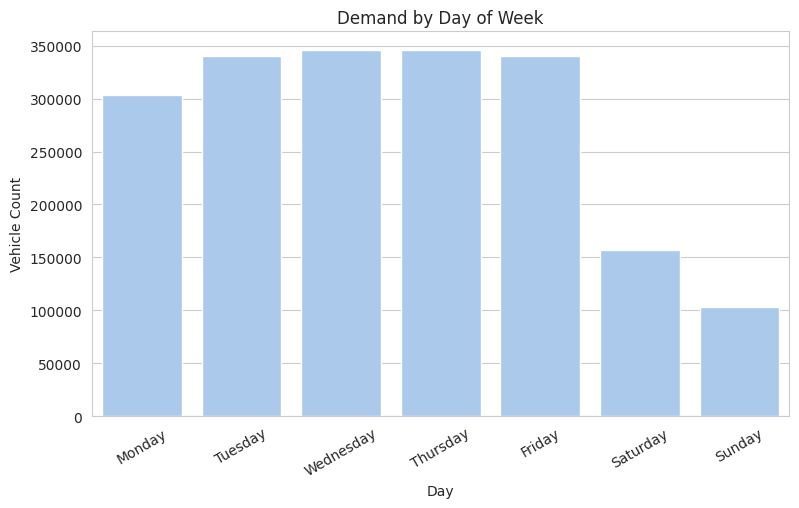

In [17]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_demand = van_truck_df.groupby("day_of_week")["vehicle_count"].sum().reset_index()
day_demand["day_of_week"] = pd.Categorical(day_demand["day_of_week"], categories=day_order, ordered=True)
day_demand = day_demand.sort_values("day_of_week")

plt.figure(figsize=(9,5))
sns.barplot(data=day_demand, x="day_of_week", y="vehicle_count")

plt.title("Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Vehicle Count")

plt.xticks(rotation=30)
plt.show()

**Heatmap Visualization:**
This step creates a heatmap to visualise logistics demand by day and hour. The pivot table helps identify patterns in delivery activity across different time periods. Heatmaps provide a clear view of peak logistics demand.

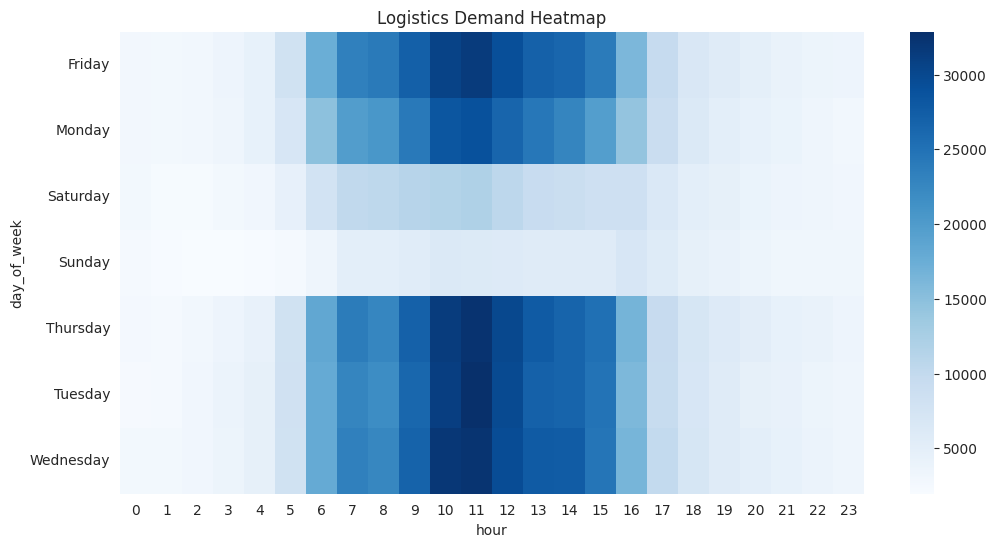

In [18]:
pivot = van_truck_df.pivot_table(
    values="vehicle_count",
    index="day_of_week",
    columns="hour",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues")

plt.title("Logistics Demand Heatmap")
plt.show()